## Setup & Start Spark Session

In [4]:
import findspark
findspark.init()
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings('ignore')

from pyspark.sql import SparkSession

OUTPUT_PATH = r"C:\Users\Ahmed\Desktop\Project Big-Data\ProjectBigData\charts"
os.makedirs(OUTPUT_PATH, exist_ok=True)

spark = SparkSession.builder \
    .appName("Taobao_CTR_BigData") \
    .config("spark.driver.memory", "4g") \
    .config("spark.executor.memory", "4g") \
    .config("spark.sql.shuffle.partitions", "8") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")
print(" Spark Version:", spark.version)
print(" Spark Session Started Successfully!")
print(f" Charts will be saved to: {OUTPUT_PATH}")

 Spark Version: 4.1.1
 Spark Session Started Successfully!
 Charts will be saved to: C:\Users\Ahmed\Desktop\Project Big-Data\ProjectBigData\charts


## Data Paths

In [5]:
DATA_PATH = r"C:\Users\Ahmed\Desktop\Project Big-Data\ProjectBigData\archive"

RAW_SAMPLE_PATH   = os.path.join(DATA_PATH, "raw_sample.csv")
AD_FEATURE_PATH   = os.path.join(DATA_PATH, "ad_feature.csv")
USER_PROFILE_PATH = os.path.join(DATA_PATH, "user_profile.csv")

print(" Data paths configured!")
print(f"   raw_sample   → {RAW_SAMPLE_PATH}")
print(f"   ad_feature   → {AD_FEATURE_PATH}")
print(f"   user_profile → {USER_PROFILE_PATH}")

 Data paths configured!
   raw_sample   → C:\Users\Ahmed\Desktop\Project Big-Data\ProjectBigData\archive\raw_sample.csv
   ad_feature   → C:\Users\Ahmed\Desktop\Project Big-Data\ProjectBigData\archive\ad_feature.csv
   user_profile → C:\Users\Ahmed\Desktop\Project Big-Data\ProjectBigData\archive\user_profile.csv


## Load Data


In [ ]:
print("Loading datasets... (may take a few minutes)\n")

raw_sample_df   = spark.read.csv(RAW_SAMPLE_PATH,   header=True, inferSchema=True)
ad_feature_df   = spark.read.csv(AD_FEATURE_PATH,   header=True, inferSchema=True)
user_profile_df = spark.read.csv(USER_PROFILE_PATH, header=True, inferSchema=True)

print("All datasets loaded successfully!")

 Loading datasets... (may take a few minutes)

 All datasets loaded successfully!


## Schema & Record Counts

In [7]:
print("=" * 60)
print(" SCHEMA & RECORD COUNTS")
print("=" * 60)

datasets = {
    "raw_sample"   : raw_sample_df,
    "ad_feature"   : ad_feature_df,
    "user_profile" : user_profile_df
}

for name, df in datasets.items():
    count = df.count()
    print(f"\n {name.upper()}")
    print(f"   Records : {count:,}")
    print(f"   Columns : {len(df.columns)}")
    print(f"   Fields  : {df.columns}")
    df.printSchema()
    print("-" * 60)

 SCHEMA & RECORD COUNTS

 RAW_SAMPLE
   Records : 26,557,961
   Columns : 6
   Fields  : ['user', 'time_stamp', 'adgroup_id', 'pid', 'nonclk', 'clk']
root
 |-- user: integer (nullable = true)
 |-- time_stamp: integer (nullable = true)
 |-- adgroup_id: integer (nullable = true)
 |-- pid: string (nullable = true)
 |-- nonclk: integer (nullable = true)
 |-- clk: integer (nullable = true)

------------------------------------------------------------

 AD_FEATURE
   Records : 846,811
   Columns : 6
   Fields  : ['adgroup_id', 'cate_id', 'campaign_id', 'customer', 'brand', 'price']
root
 |-- adgroup_id: integer (nullable = true)
 |-- cate_id: integer (nullable = true)
 |-- campaign_id: integer (nullable = true)
 |-- customer: integer (nullable = true)
 |-- brand: string (nullable = true)
 |-- price: double (nullable = true)

------------------------------------------------------------

 USER_PROFILE
   Records : 1,061,768
   Columns : 9
   Fields  : ['userid', 'cms_segid', 'cms_group_id', 'f

## Sample Preview

In [8]:
print(" SAMPLE DATA PREVIEW")
print("=" * 60)

for name, df in datasets.items():
    print(f"\n {name.upper()} — First 5 rows:")
    df.show(5, truncate=False)
    print("-" * 60)

 SAMPLE DATA PREVIEW

 RAW_SAMPLE — First 5 rows:
+------+----------+----------+-----------+------+---+
|user  |time_stamp|adgroup_id|pid        |nonclk|clk|
+------+----------+----------+-----------+------+---+
|581738|1494137644|1         |430548_1007|1     |0  |
|449818|1494638778|3         |430548_1007|1     |0  |
|914836|1494650879|4         |430548_1007|1     |0  |
|914836|1494651029|5         |430548_1007|1     |0  |
|399907|1494302958|8         |430548_1007|1     |0  |
+------+----------+----------+-----------+------+---+
only showing top 5 rows
------------------------------------------------------------

 AD_FEATURE — First 5 rows:
+----------+-------+-----------+--------+------+-----+
|adgroup_id|cate_id|campaign_id|customer|brand |price|
+----------+-------+-----------+--------+------+-----+
|63133     |6406   |83237      |1       |95471 |170.0|
|313401    |6406   |83237      |1       |87331 |199.0|
|248909    |392    |83237      |1       |32233 |38.0 |
|208458    |392    |


## 

In [9]:
print("=" * 60)
print(" PROJECT SUMMARY")
print("=" * 60)

raw_count  = raw_sample_df.count()
ad_count   = ad_feature_df.count()
user_count = user_profile_df.count()
total      = raw_count + ad_count + user_count

print(f"  raw_sample   : {raw_count:>15,} records")
print(f"  ad_feature   : {ad_count:>15,} records")
print(f"  user_profile : {user_count:>15,} records")
print(f"  {'─'*35}")
print(f"  TOTAL        : {total:>15,} records")
print(f"\n  Problem Type  : Binary Classification (CTR Prediction)")
print(f"  Target Column : noclk (0 = click, 1 = no click)")
print(f"  Training Days : 2017-05-06 → 2017-05-12")
print(f"  Test Day      : 2017-05-13")

 PROJECT SUMMARY
  raw_sample   :      26,557,961 records
  ad_feature   :         846,811 records
  user_profile :       1,061,768 records
  ───────────────────────────────────
  TOTAL        :      28,466,540 records

  Problem Type  : Binary Classification (CTR Prediction)
  Target Column : noclk (0 = click, 1 = no click)
  Training Days : 2017-05-06 → 2017-05-12
  Test Day      : 2017-05-13


## Import Libraries

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import pandas as pd
from pyspark.sql.functions import (
    col, count, when, isnan, isnull, 
    round as spark_round, from_unixtime,
    dayofweek, hour, mean, sum as spark_sum
)

sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12

print("✅ Libraries imported!")

✅ Libraries imported!


## Target Variable Analysis

 TARGET VARIABLE ANALYSIS (clk)
       label    count  percentage
No Click (0) 25191905       94.86
   Click (1)  1366056        5.14


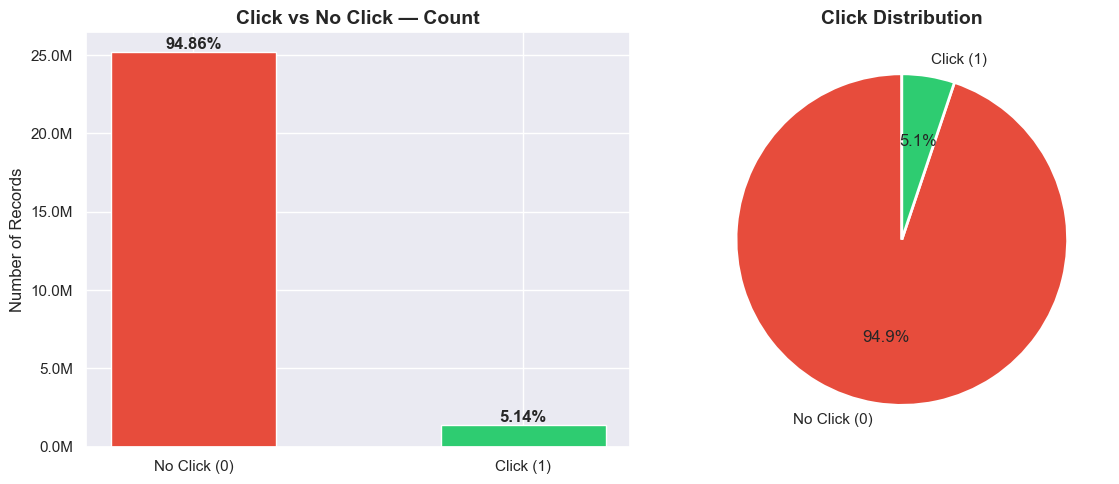

 Target distribution analyzed!


In [ ]:
print(" TARGET VARIABLE ANALYSIS (clk)")
print("=" * 50)

target_dist = raw_sample_df.groupBy("clk") \
    .count() \
    .orderBy("clk") \
    .toPandas()

target_dist["percentage"] = (
    target_dist["count"] / target_dist["count"].sum() * 100
).round(2)

target_dist["label"] = target_dist["clk"].map({
    0: "No Click (0)", 
    1: "Click (1)"
})

print(target_dist[["label", "count", "percentage"]].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(
    target_dist["label"], 
    target_dist["count"],
    color=["#e74c3c", "#2ecc71"],
    edgecolor="white",
    width=0.5
)
axes[0].set_title("Click vs No Click — Count", fontsize=14, fontweight='bold')
axes[0].set_ylabel("Number of Records")
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M")
)
for bar, val in zip(axes[0].patches, target_dist["percentage"]):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 200000,
        f"{val}%",
        ha='center', fontsize=12, fontweight='bold'
    )

axes[1].pie(
    target_dist["count"],
    labels=target_dist["label"],
    autopct="%1.1f%%",
    colors=["#e74c3c", "#2ecc71"],
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)
axes[1].set_title("Click Distribution", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig("target_distribution.png", dpi=150, bbox_inches='tight')
plt.show()
print(" Target distribution analyzed!")

## Missing Values Analysis

 MISSING VALUES ANALYSIS

 Analyzing raw_sample...
 raw_sample (Records: 26,557,961): No missing values!

 Analyzing ad_feature...
 ad_feature (Records: 846,811): No missing values!

 Analyzing user_profile...

 user_profile — Total Records: 1,061,768
               Column  Missing  Percentage
         pvalue_level   575917       54.24
new_user_class_level    344920       32.49


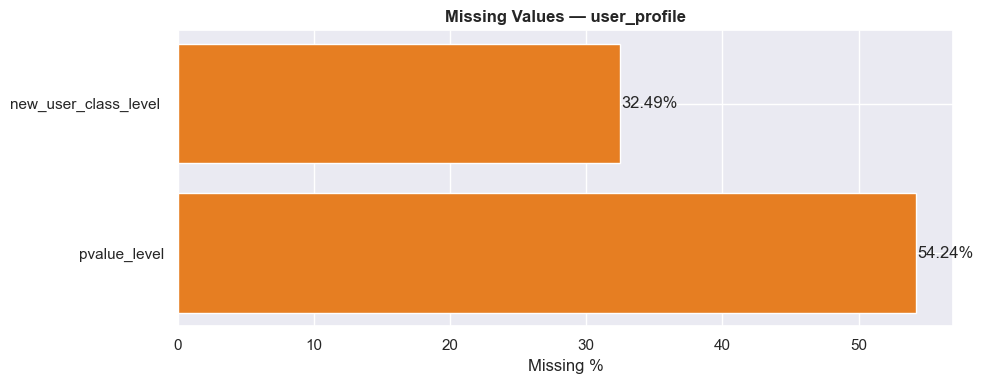


 Missing values analysis done!


In [ ]:
print(" MISSING VALUES ANALYSIS")
print("=" * 50)

from pyspark.sql.functions import col, isnull, isnan, sum as spark_sum, count

def missing_values_fast(df, name):
    print(f"\n Analyzing {name}...")
    
    total = df.count()
    
    null_expr = [
        spark_sum(
            when(isnull(c), 1).otherwise(0)
        ).alias(c)
        for c in df.columns
    ]
    
    null_counts = df.select(null_expr).collect()[0].asDict()
    
    missing_data = [
        {
            "Column"     : col_name,
            "Missing"    : null_val,
            "Percentage" : round(null_val / total * 100, 2)
        }
        for col_name, null_val in null_counts.items()
        if null_val > 0
    ]
    
    if missing_data:
        missing_df = pd.DataFrame(missing_data).sort_values(
            "Percentage", ascending=False
        )
        print(f"\n {name} — Total Records: {total:,}")
        print(missing_df.to_string(index=False))
        
        plt.figure(figsize=(10, 4))
        plt.barh(
            missing_df["Column"],
            missing_df["Percentage"],
            color="#e67e22"
        )
        plt.xlabel("Missing %")
        plt.title(f"Missing Values — {name}", fontweight='bold')
        for i, val in enumerate(missing_df["Percentage"]):
            plt.text(val + 0.1, i, f"{val}%", va='center')
        plt.tight_layout()
        plt.savefig(f"missing_{name}.png", dpi=150, bbox_inches='tight')
        plt.show()
    else:
        print(f" {name} (Records: {total:,}): No missing values!")

missing_values_fast(raw_sample_df,   "raw_sample")
missing_values_fast(ad_feature_df,   "ad_feature")
missing_values_fast(user_profile_df, "user_profile")

print("\n Missing values analysis done!")

## CTR by Demographics

👥 CTR ANALYSIS BY USER DEMOGRAPHICS


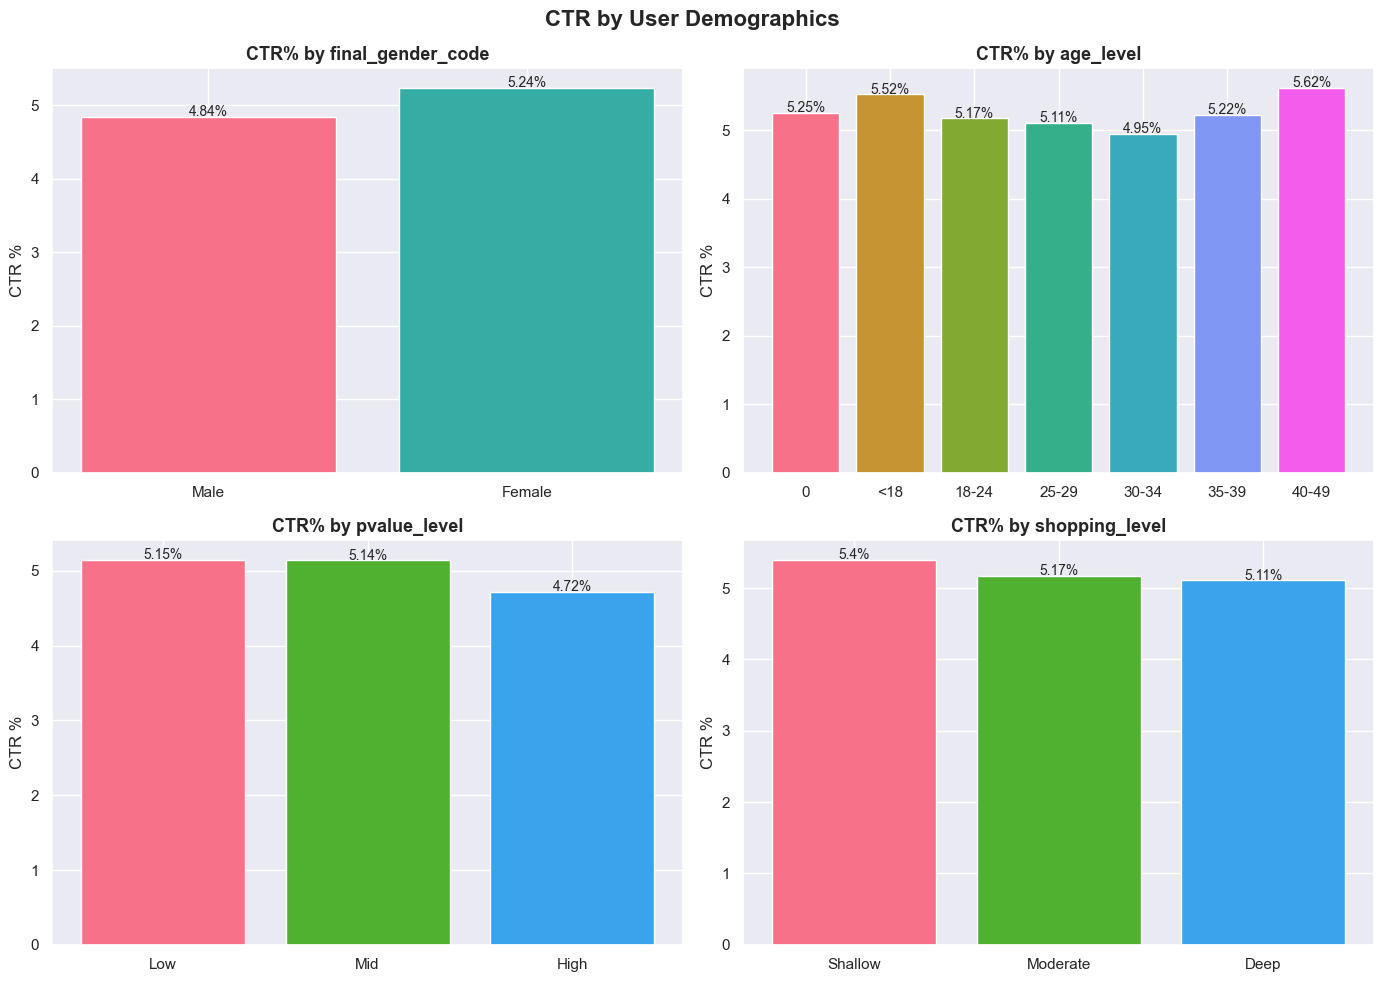

 Demographics analysis done!


In [13]:
print("👥 CTR ANALYSIS BY USER DEMOGRAPHICS")
print("=" * 50)

from pyspark.sql.functions import mean, col, when
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

joined_df = raw_sample_df.join(
    user_profile_df,
    raw_sample_df["user"] == user_profile_df["userid"],
    "left"
)

demo_cols = {
    "final_gender_code" : {1: "Male", 2: "Female"},
    "age_level"         : {1:"<18", 2:"18-24", 3:"25-29", 4:"30-34", 5:"35-39", 6:"40-49", 7:"50+"},
    "pvalue_level"      : {1: "Low", 2: "Mid", 3: "High"},
    "shopping_level"    : {1: "Shallow", 2: "Moderate", 3: "Deep"}
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (col_name, label_map) in enumerate(demo_cols.items()):
    ctr_data = joined_df.groupBy(col_name).agg(
        spark_round(mean("clk") * 100, 2).alias("CTR%")
    ).dropna().orderBy(col_name).toPandas()

    ctr_data[col_name] = ctr_data[col_name].map(label_map).fillna(ctr_data[col_name].astype(str))

    axes[idx].bar(
        ctr_data[col_name].astype(str),
        ctr_data["CTR%"],
        color=sns.color_palette("husl", len(ctr_data)),
        edgecolor="white"
    )
    axes[idx].set_title(f"CTR% by {col_name}", fontsize=13, fontweight='bold')
    axes[idx].set_ylabel("CTR %")
    for bar, val in zip(axes[idx].patches, ctr_data["CTR%"]):
        axes[idx].text(bar.get_x() + bar.get_width()/2,
                       bar.get_height() + 0.01, f"{val}%", ha='center', fontsize=10)

plt.suptitle("CTR by User Demographics", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig("ctr_demographics.png", dpi=150, bbox_inches='tight')
plt.show()
print(" Demographics analysis done!")

## CTR by Hour

 CTR ANALYSIS BY HOUR OF DAY


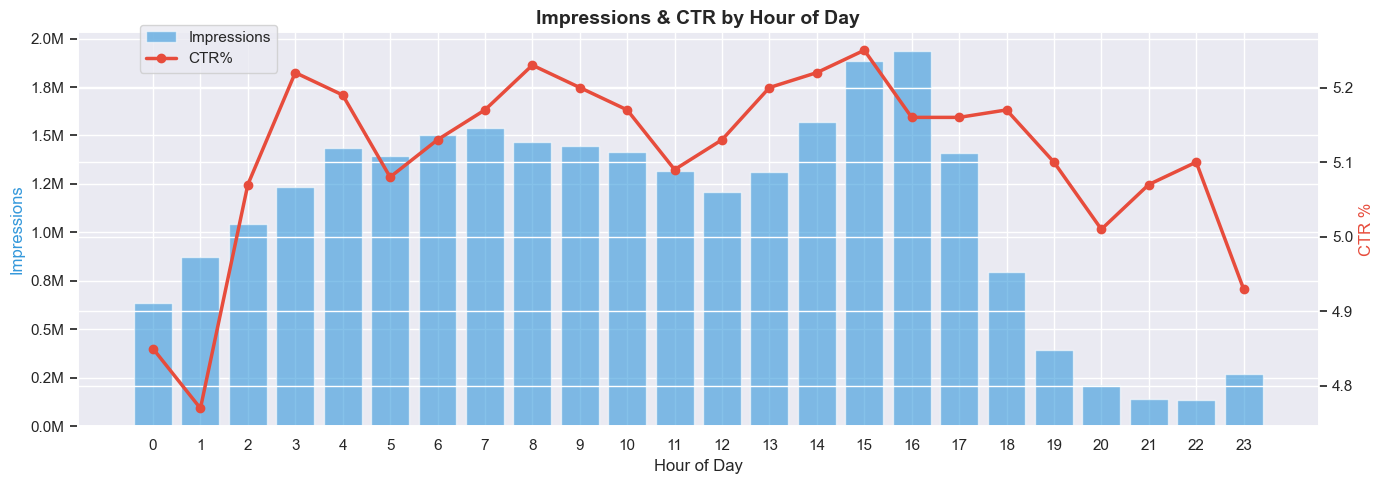

 Hourly CTR done!


In [14]:
print(" CTR ANALYSIS BY HOUR OF DAY")

from pyspark.sql.functions import hour, from_unixtime, sum as spark_sum
import matplotlib.ticker as mticker

hourly_ctr = raw_sample_df.withColumn(
    "hour", hour(from_unixtime("time_stamp"))
).groupBy("hour").agg(
    count("*").alias("total_impressions"),
    spark_sum("clk").alias("total_clicks"),
    spark_round(mean("clk") * 100, 2).alias("CTR%")
).orderBy("hour").toPandas()

fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.bar(hourly_ctr["hour"], hourly_ctr["total_impressions"], color="#3498db", alpha=0.6, label="Impressions")
ax1.set_xlabel("Hour of Day")
ax1.set_ylabel("Impressions", color="#3498db")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))

ax2 = ax1.twinx()
ax2.plot(hourly_ctr["hour"], hourly_ctr["CTR%"], color="#e74c3c", marker="o", linewidth=2.5, label="CTR%")
ax2.set_ylabel("CTR %", color="#e74c3c")

plt.title("Impressions & CTR by Hour of Day", fontsize=14, fontweight='bold')
ax1.set_xticks(range(0, 24))
fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.95))
plt.tight_layout()
plt.savefig("hourly_ctr.png", dpi=150, bbox_inches='tight')
plt.show()
print(" Hourly CTR done!")

## Top Categories & Brands

 TOP CATEGORIES & BRANDS BY CTR


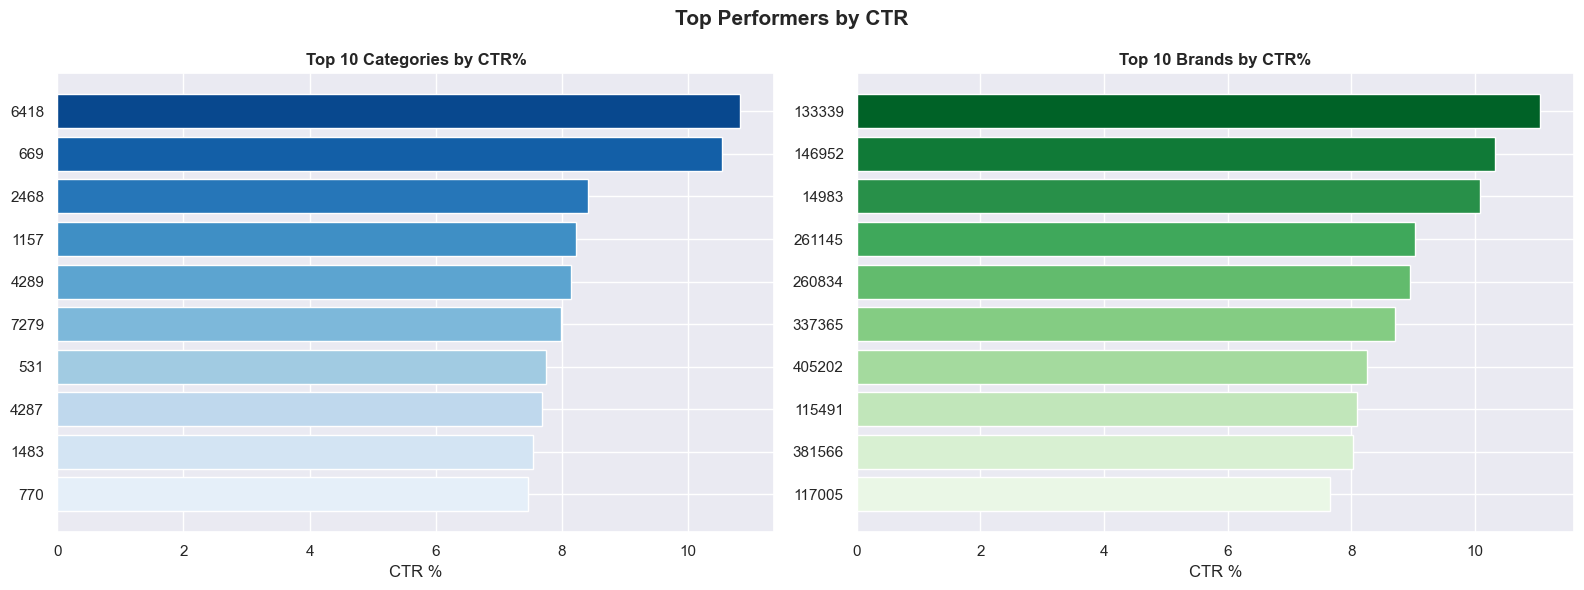

 Categories & Brands done!


In [15]:
print(" TOP CATEGORIES & BRANDS BY CTR")

ads_joined = raw_sample_df.join(ad_feature_df, "adgroup_id", "left")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_cates = ads_joined.groupBy("cate_id").agg(
    count("*").alias("impressions"),
    spark_round(mean("clk") * 100, 2).alias("CTR%")
).filter(col("impressions") > 10000).orderBy(col("CTR%").desc()).limit(10).toPandas()

axes[0].barh(top_cates["cate_id"].astype(str), top_cates["CTR%"],
             color=sns.color_palette("Blues_r", 10))
axes[0].set_title("Top 10 Categories by CTR%", fontweight='bold')
axes[0].set_xlabel("CTR %")
axes[0].invert_yaxis()

top_brands = ads_joined.groupBy("brand").agg(
    count("*").alias("impressions"),
    spark_round(mean("clk") * 100, 2).alias("CTR%")
).filter(col("impressions") > 5000).orderBy(col("CTR%").desc()).limit(10).toPandas()

axes[1].barh(top_brands["brand"].astype(str), top_brands["CTR%"],
             color=sns.color_palette("Greens_r", 10))
axes[1].set_title("Top 10 Brands by CTR%", fontweight='bold')
axes[1].set_xlabel("CTR %")
axes[1].invert_yaxis()

plt.suptitle("Top Performers by CTR", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_PATH + "top_categories_brands.png", dpi=150, bbox_inches='tight')
plt.show()
print(" Categories & Brands done!")

## EDA Summary

In [16]:
print("=" * 60)
print(" EDA COMPLETE SUMMARY")
print("=" * 60)

total     = raw_sample_df.count()
clicks    = raw_sample_df.filter(col("clk") == 1).count()
no_clicks = total - clicks

print(f"""
   Dataset Overview:
     Total Records    : {total:,}
     Total Users      : {raw_sample_df.select('user').distinct().count():,}
     Total Ads        : {raw_sample_df.select('adgroup_id').distinct().count():,}

   Target Variable (clk):
     Clicks    (1)    : {clicks:,}  ({clicks/total*100:.2f}%)
     No Click  (0)    : {no_clicks:,} ({no_clicks/total*100:.2f}%)
    EDA Done 
    
""")
print(" 01_EDA.ipynb — Complete!")
spark.stop()

 EDA COMPLETE SUMMARY

   Dataset Overview:
     Total Records    : 26,557,961
     Total Users      : 1,141,729
     Total Ads        : 846,811

   Target Variable (clk):
     Clicks    (1)    : 1,366,056  (5.14%)
     No Click  (0)    : 25,191,905 (94.86%)
    EDA Done 


 01_EDA.ipynb — Complete!
